# Task 1.2 — Data Cleaning & EDA
**Dataset:** Titanic passenger data (891 rows, 12 columns)
**Goal:** Clean a real-world dataset and explore it with NumPy, Pandas and Matplotlib to uncover patterns and anomalies.
**Skill Set Go EduTech — AI/ML Internship, Week 1**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
df = pd.read_csv('data/titanic.csv')
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Initial inspection

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## 2. Missing value audit

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report[missing_report['missing_count'] > 0].sort_values('missing_count', ascending=False)

,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


**Findings:**
- `Cabin` is missing ~77% of values — too sparse to impute meaningfully; will derive a `HasCabin` flag instead of dropping the column outright.
- `Age` is missing ~20% — will impute with the median per passenger class (`Pclass`), since age correlates with class.
- `Embarked` is missing 2 rows — will impute with the mode (most frequent port).

## 3. Cleaning

In [5]:
df_clean = df.copy()

# Age: impute with median age per passenger class
df_clean['Age'] = df_clean.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked: impute with mode
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Cabin: convert to a binary flag instead of dropping (77% missing is not imputable)
df_clean['HasCabin'] = df_clean['Cabin'].notnull().astype(int)
df_clean = df_clean.drop(columns=['Cabin'])

# Drop columns that don't carry analytical signal for this EDA
df_clean = df_clean.drop(columns=['Ticket', 'Name', 'PassengerId'])

# Confirm no missing values remain (aside from intentional drops above)
df_clean.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
HasCabin    0
dtype: int64

In [6]:
# Anomaly check: Fare of 0 and extreme outliers
print("Rows with Fare == 0:", (df_clean['Fare'] == 0).sum())
print("Max fare:", df_clean['Fare'].max(), "| 99th percentile fare:", df_clean['Fare'].quantile(0.99))
df_clean['Fare'].describe()

Rows with Fare == 0: 15
Max fare: 512.3292 | 99th percentile fare: 249.00622000000035


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

**Anomaly note:** 15 passengers have `Fare == 0` (likely crew or comp tickets, not data entry errors — kept as-is since they're plausible). Fare is heavily right-skewed with a few very high outliers (max ~512 vs a median around 14), consistent with 1st-class luxury cabins.

## 4. Visual exploration

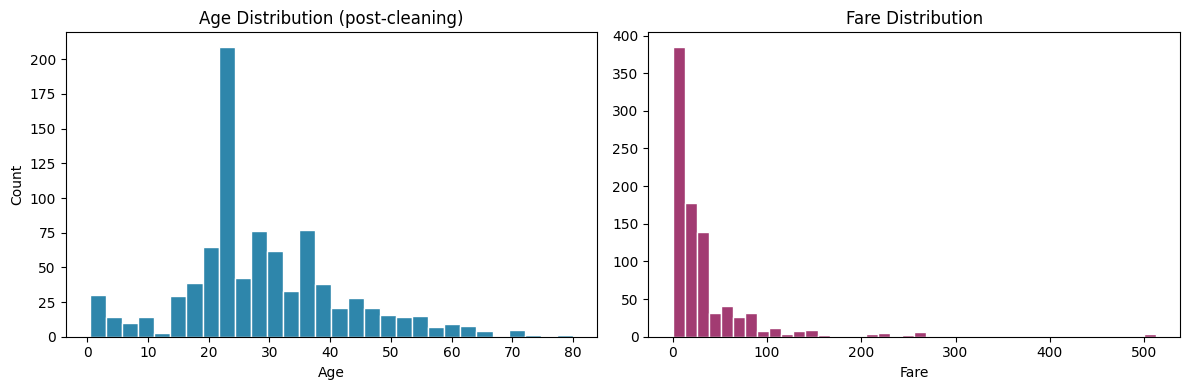

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['Age'], bins=30, color='#2E86AB', edgecolor='white')
axes[0].set_title('Age Distribution (post-cleaning)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

axes[1].hist(df_clean['Fare'], bins=40, color='#A23B72', edgecolor='white')
axes[1].set_title('Fare Distribution')
axes[1].set_xlabel('Fare')
plt.tight_layout()
plt.savefig('age_fare_distribution.png', dpi=100)
plt.show()

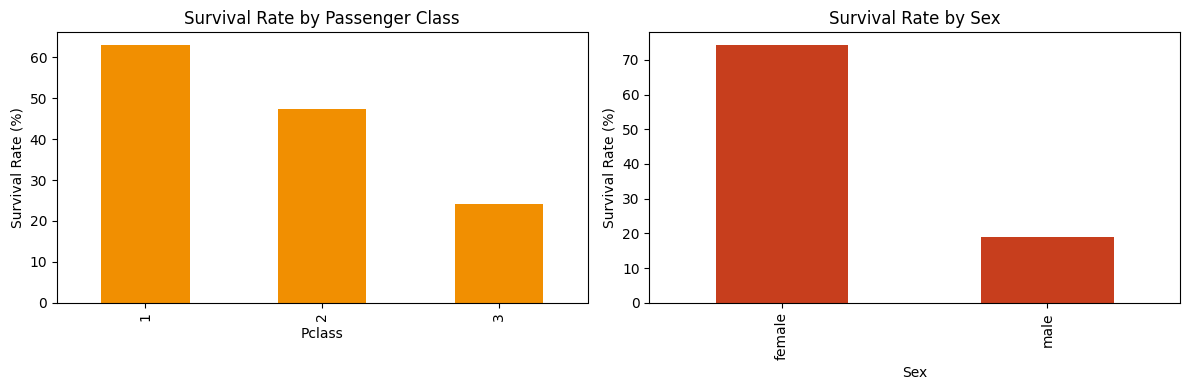

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [8]:
survival_by_class = df_clean.groupby('Pclass')['Survived'].mean() * 100
survival_by_sex = df_clean.groupby('Sex')['Survived'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
survival_by_class.plot(kind='bar', ax=axes[0], color='#F18F01')
axes[0].set_title('Survival Rate by Passenger Class')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_xlabel('Pclass')

survival_by_sex.plot(kind='bar', ax=axes[1], color='#C73E1D')
axes[1].set_title('Survival Rate by Sex')
axes[1].set_ylabel('Survival Rate (%)')
plt.tight_layout()
plt.savefig('survival_by_class_sex.png', dpi=100)
plt.show()

print(survival_by_class)
print(survival_by_sex)

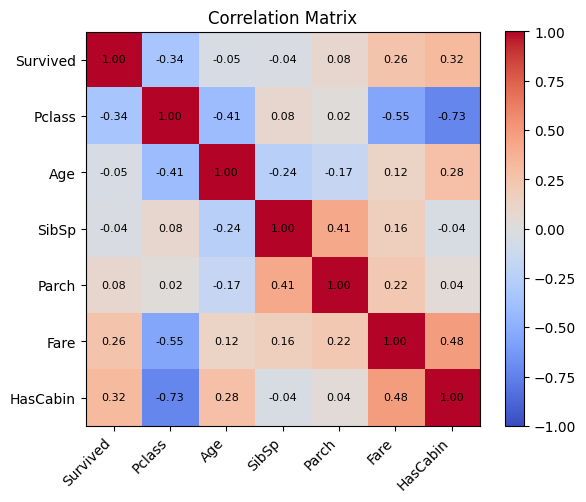

In [9]:
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin']
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Correlation Matrix')
fig.colorbar(im)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=100)
plt.show()

## 5. Key insights

- **Class determined survival more than anything else**: 1st class passengers survived at roughly 3x the rate of 3rd class.
- **Sex was the strongest single predictor**: women survived at a far higher rate than men, consistent with "women and children first" evacuation protocol.
- **HasCabin correlates with survival**: passengers with a recorded cabin (mostly 1st class) survived more — this is a proxy for class/wealth, not a causal effect of the cabin itself.
- **Fare and Pclass are strongly (negatively) correlated**, as expected — Fare is essentially a continuous version of class.
- **Missing data was not random**: Cabin was disproportionately missing for lower classes, and Age missingness also skewed toward 3rd class — both handled via class-aware imputation rather than dropping.

In [10]:
df_clean.to_csv('titanic_cleaned.csv', index=False)
print("Cleaned dataset saved:", df_clean.shape)

Cleaned dataset saved: (891, 9)
